<a href="https://colab.research.google.com/github/tofighi/tutorials/blob/master/AI/Logistic_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Logistic Regression Course Module

Welcome to the Logistic Regression module. This notebook is designed for both undergraduate and graduate students and is split into four parts:

* **Part 1: Basic Logistic Regression** — Fundamental concepts, classification vs. regression, odds ratio, logit, sigmoid, cross-entropy loss, and simple numerical examples. *No calculus or matrix derivations required.*
* **Part 2: Advanced Logistic Regression** — Rigorous mathematical derivations (using calculus and the chain rule) and generalization to multi-class classification via Softmax Regression.
* **Part 3: Code for Basic Logistic Regression** — Standard library-based Python implementations using Scikit-Learn and performance evaluation metrics.
* **Part 4: Code for Advanced Logistic Regression** — From-scratch NumPy implementations of binary Logistic Regression and multi-class Softmax Regression with gradient descent.

---

## Table of Contents
1. **[Part 1: Basic Logistic Regression](#part_1)**
   * [1.1 Classification vs. Regression & Limits of OLS](#section_1_1)
   * [1.2 The Logit Hypothesis & Sigmoid Function](#section_1_2)
   * [1.3 Loss Function: Cross-Entropy Loss (Log Loss)](#section_1_3)
   * [1.4 Cost Function (Mean Cross-Entropy Loss)](#section_1_4)
   * [1.5 Optimization: Finding the Best Parameters via Gradient Descent](#section_1_5)
   * [1.6 Consolidated Numerical Example](#section_1_6)
2. **[Part 2: Advanced Logistic Regression & Softmax Regression](#part_2)**
   * [2.1 Derivation of the Gradient (Calculus & Chain Rule)](#section_2_1)
   * [2.2 Softmax Regression (Multi-Class Generalization)](#section_2_2)
   * [2.3 Mathematical Formulation of Regularization (Ridge & Lasso)](#section_2_3)
3. **[Part 3: Code for Basic Logistic Regression](#part_3)**
   * [3.1 Visualizing the Sigmoid Function & Decision Boundary](#section_3_1)
   * [3.2 Scikit-Learn Logistic Regression (Hours Studied Dataset)](#section_3_2)
   * [3.3 Performance Evaluation: Confusion Matrix & Metrics](#section_3_3)
4. **[Part 4: Code for Advanced Logistic Regression](#part_4)**
   * [4.1 Implementing Binary Logistic Regression from Scratch](#section_4_1)
   * [4.2 Implementing Softmax Regression from Scratch](#section_4_2)


<a name="part_1"></a>
# Part 1: Basic Logistic Regression

This section covers the fundamental building blocks of logistic regression using intuitive concepts, basic algebra, and probability. **No calculus or matrix derivations are needed here** — those are covered in Part 2.

---

<a name="section_1_1"></a>
### 1.1 Classification vs. Regression & Limits of OLS

In **Linear Regression**, we predicted a continuous output $y \in \mathbb{R}$ (such as home prices or life expectancy) from inputs $x$. However, many real-world problems require predicting a **categorical outcome** (such as credit default vs. non-default, email spam vs. ham, or disease diagnosis). This is **classification**.

For **binary classification**, the target variable $y$ can take only two nominal values: $0$ (the negative class) or $1$ (the positive class).

#### Why Ordinary Least Squares (OLS) Fails for Classification:
1. **Out-of-Bound Predictions:** OLS can predict values less than $0$ or greater than $1$, which makes no sense for probabilities.
2. **Outlier Sensitivity:** OLS tries to minimize squared distances. Adding a data point far to the right that is easily classified can drastically shift the regression line, altering the decision boundary and causing classification errors.
3. **Non-Convexity:** If we use a non-linear hypothesis with MSE, the resulting cost function becomes non-convex, which has many local minima.

Therefore, we need a model that output values strictly bounded between $0$ and $1$, representing the probability $p = P(y=1|x)$.


<a name="section_1_2"></a>
### 1.2 The Logit Hypothesis & Sigmoid Function

Instead of modeling the probability $p$ directly as a linear function of $x$, we model the **logarithm of the odds** (also called the **logit**).

#### 1. Odds and Odds Ratio
The **odds** of an event happening is the ratio of the probability of the event occurring ($p$) to the probability of it not occurring ($1-p$):
$$\text{Odds} = \frac{p}{1-p} \tag{1.1}$$

If $p = 0.8$, then the odds are $0.8 / 0.2 = 4$ (or 4 to 1).

#### 2. The Logit Transformation
We model the log of the odds as a linear combination of features:
$$\log(\text{Odds}) = \log\left(\frac{p}{1-p}\right) = \theta_0 + \theta_1 x_1 + \dots + \theta_d x_d = \theta^T x \tag{1.2}$$

While $p$ is strictly bounded in $[0, 1]$, the odds range in $[0, \infty)$, and the log-odds (logit) ranges from $-\infty$ to $+\infty$.

#### 3. The Sigmoid Function
To find $p$ as a function of the input vector $x$ and parameter vector $\theta$, we invert the logit transformation (solve Eq. 1.2 for $p$):
$$e^{\theta^T x} = \frac{p}{1-p} \implies e^{\theta^T x}(1-p) = p \implies e^{\theta^T x} - p e^{\theta^T x} = p \implies p(1 + e^{\theta^T x}) = e^{\theta^T x}$$
$$p = \frac{e^{\theta^T x}}{1 + e^{\theta^T x}} = \frac{1}{1 + e^{-\theta^T x}}$$

This is the **Sigmoid (or Logistic) function**, denoted by $\sigma(z)$:
$$\boxed{h_\theta(x) = P(y=1|x) = \sigma(\theta^T x) = \frac{1}{1 + e^{-\theta^T x}}} \tag{1.3}$$
where $z = \theta^T x$ is the linear prediction.

> **Numerical Example 1.1:**
> Let the model parameters be $\theta_0 = -2.0$ and $\theta_1 = 0.5$ for a single feature $x$. If $x = 6.0$:
> $$z = \theta_0 + \theta_1 x = -2.0 + 0.5 \times 6.0 = -2.0 + 3.0 = 1.0$$
> $$p = \sigma(1.0) = \frac{1}{1 + e^{-1.0}} \approx \frac{1}{1 + 0.3679} \approx 0.7311$$
> The model predicts a $73.11\%$ probability that $y = 1$ for $x = 6.0$.


<a name="section_1_3"></a>
### 1.3 Loss Function: Cross-Entropy Loss (Log Loss)

To measure how well the model predicts the true labels, we need a loss function. In linear regression, we used the squared residual $(\hat{y} - y)^2$. If we used squared residuals for logistic regression, the cost function would be non-convex and difficult to optimize because $h_\theta(x)$ is non-linear.

Instead, we employ the **Cross-Entropy Loss (Log Loss)**. For a single training example $(x^{(i)}, y^{(i)})$, it is defined as:
$$Loss(y^{(i)}, p^{(i)}) = \begin{cases} -\log(p^{(i)}) & \text{if } y^{(i)} = 1 \\ -\log(1 - p^{(i)}) & \text{if } y^{(i)} = 0 \end{cases} \tag{1.4}$$
where $p^{(i)} = h_\theta(x^{(i)})$ is the predicted probability.

#### Intuition:
* **If $y^{(i)} = 1$:** The loss is $-\log(p^{(i)})$. If $p^{(i)} \to 1$ (correct prediction), the loss approaches $-\log(1) = 0$. If $p^{(i)} \to 0$ (confident incorrect prediction), the loss approaches $\infty$.
* **If $y^{(i)} = 0$:** The loss is $-\log(1-p^{(i)})$. If $p^{(i)} \to 0$ (correct prediction), the loss approaches $-\log(1) = 0$. If $p^{(i)} \to 1$ (confident incorrect prediction), the loss approaches $\infty$.

We can write this compactly in a single equation:
$$\boxed{Loss(y^{(i)}, p^{(i)}) = -\left[ y^{(i)} \log(p^{(i)}) + (1 - y^{(i)}) \log(1 - p^{(i)}) \right]} \tag{1.5}$$

> **Numerical Example 1.2:**
> Suppose $y^{(i)} = 1$ and the model predicts $p^{(i)} = 0.7311$:
> $$Loss = -[1 \times \log(0.7311) + 0] = -(-0.3132) \approx 0.3132$$
> If instead the actual class was $y^{(i)} = 0$:
> $$Loss = -[0 + (1 - 0) \times \log(1 - 0.7311)] = -\log(0.2689) \approx 1.3134$$
> The loss is much higher because the model predicted a high probability ($73.11\%$) for class 1, when the actual label was 0.


<a name="section_1_4"></a>
### 1.4 Cost Function (Mean Cross-Entropy Loss)

The **cost function** $J(\theta)$ is the average of the Cross-Entropy loss over the entire dataset of $m$ training examples:
$$\boxed{J(\theta) = -\frac{1}{m} \sum_{i=1}^{m} \left[ y^{(i)} \log\left(h_\theta(x^{(i)})\right) + (1 - y^{(i)}) \log\left(1 - h_\theta(x^{(i)})\right) \right]} \tag{1.6}$$


<a name="section_1_5"></a>
### 1.5 Optimization: Finding the Best Parameters via Gradient Descent

To find the parameters $\theta$ that minimize $J(\theta)$, we use **Gradient Descent**. Starting with an initial guess, we iteratively update each parameter:
$$\theta_j := \theta_j - \alpha \frac{\partial J(\theta)}{\partial \theta_j} \tag{1.7}$$
where $\alpha > 0$ is the learning rate.

The partial derivative of the cost function with respect to parameter $\theta_j$ is:
$$\boxed{\frac{\partial J(\theta)}{\partial \theta_j} = \frac{1}{m} \sum_{i=1}^{m} \left( h_\theta(x^{(i)}) - y^{(i)} \right) x_j^{(i)}} \tag{1.8}$$
*(where we assume $x_0^{(i)} = 1$ for the intercept term $\theta_0$)*

> **Crucial Analogy:** Notice that the gradient formula (Eq. 1.8) has the exact same mathematical form as the gradient formula for Linear Regression! The only difference is that $h_\theta(x)$ is now the sigmoid function $\sigma(\theta^T x)$ rather than the linear function $\theta^T x$. This is a beautiful property of generalized linear models.


<a name="section_1_6"></a>
### 1.6 Consolidated Numerical Example

Let us perform one step of Gradient Descent manually to see how the numbers update.

**Dataset:**
* $x^{(1)} = 2$, $y^{(1)} = 0$
* $x^{(2)} = 15$, $y^{(2)} = 0$
* $x^{(3)} = 33$, $y^{(3)} = 1$
* $m = 3$ (number of examples), $d = 1$ (number of features)

We use a 2-parameter model: $h_\theta(x) = \sigma(\theta_0 + \theta_1 x)$, meaning $x_0 = 1$ and $x_1 = x$.

**Initial Parameters:** $\theta_0 = -3.0$, $\theta_1 = 0.1$. **Learning Rate:** $\alpha = 0.1$.

#### Step 1: Compute Predictions ($h_\theta(x^{(i)})$)
* **For $i=1$ ($x^{(1)}=2$):**
  $$z^{(1)} = -3.0 + 0.1 \times 2 = -2.8 \implies p^{(1)} = \sigma(-2.8) = \frac{1}{1 + e^{2.8}} \approx 0.0574$$
* **For $i=2$ ($x^{(2)}=15$):**
  $$z^{(2)} = -3.0 + 0.1 \times 15 = -1.5 \implies p^{(2)} = \sigma(-1.5) = \frac{1}{1 + e^{1.5}} \approx 0.1824$$
* **For $i=3$ ($x^{(3)}=33$):**
  $$z^{(3)} = -3.0 + 0.1 \times 33 = 0.3 \implies p^{(3)} = \sigma(0.3) = \frac{1}{1 + e^{-0.3}} \approx 0.5744$$

#### Step 2: Compute Cost ($J(\theta)$)
* $Loss_1 = -[0 + \log(1 - 0.0574)] \approx 0.0592$
* $Loss_2 = -[0 + \log(1 - 0.1824)] \approx 0.2014$
* $Loss_3 = -[1 \times \log(0.5744) + 0] = -\log(0.5744) \approx 0.5544$
* **Total Cost:**
  $$J(\theta) = \frac{1}{3} (0.0592 + 0.2014 + 0.5544) = \frac{0.8150}{3} \approx 0.2717$$

#### Step 3: Compute Gradients
First, we calculate the residuals $(p^{(i)} - y^{(i)})$:
* $i=1$: $0.0574 - 0 = +0.0574$
* $i=2$: $0.1824 - 0 = +0.1824$
* $i=3$: $0.5744 - 1 = -0.4256$

Now we compute the partial derivatives:
* **For Intercept $\theta_0$ ($x_0 = 1$):**
  $$\frac{\partial J}{\partial \theta_0} = \frac{1}{3} \sum_{i=1}^3 (p^{(i)} - y^{(i)}) \times 1 = \frac{1}{3}(0.0574 + 0.1824 - 0.4256) = \frac{-0.1858}{3} \approx -0.0619$$
* **For Slope $\theta_1$ ($x_1 = x$):**
  $$\frac{\partial J}{\partial \theta_1} = \frac{1}{3} \sum_{i=1}^3 (p^{(i)} - y^{(i)}) x^{(i)} = \frac{1}{3} \left( 0.0574 \times 2 + 0.1824 \times 15 - 0.4256 \times 33 \right)$$
  $$\frac{\partial J}{\partial \theta_1} = \frac{1}{3}(0.1148 + 2.7360 - 14.0448) = \frac{-11.1940}{3} \approx -3.7313$$

#### Step 4: Parameter Update
* $\theta_0 := \theta_0 - \alpha \frac{\partial J}{\partial \theta_0} = -3.0 - 0.1 \times (-0.0619) \approx -2.9938$
* $\theta_1 := \theta_1 - \alpha \frac{\partial J}{\partial \theta_1} = 0.1 - 0.1 \times (-3.7313) \approx 0.4731$


<a name="part_2"></a>
# Part 2: Advanced Logistic Regression & Softmax Regression

> **[ADVANCED CONTENT]**
>
> This section contains formal mathematical derivations using calculus, the chain rule, and vector notation, as well as multi-class classification concepts (Softmax Regression).

---

<a name="section_2_1"></a>
### 2.1 Derivation of the Gradient (Calculus & Chain Rule)

We want to derive Eq. 1.8: the derivative of the Mean Cross-Entropy Cost function $J(\theta)$ with respect to $\theta_j$.

#### Step 1: Derivative of the Sigmoid Function
Let $\sigma(z) = \frac{1}{1 + e^{-z}}$. We find its derivative $\sigma'(z)$:
$$\sigma'(z) = \frac{d}{dz}\left( (1 + e^{-z})^{-1} \right) = -(1 + e^{-z})^{-2} \times (-e^{-z}) = \frac{e^{-z}}{(1 + e^{-z})^2}$$
We split the fraction:
$$\sigma'(z) = \frac{1}{1 + e^{-z}} \times \frac{e^{-z}}{1 + e^{-z}} = \sigma(z) \left( \frac{1 + e^{-z} - 1}{1 + e^{-z}} \right) = \sigma(z) \left( 1 - \frac{1}{1 + e^{-z}} \right)$$
$$\boxed{\sigma'(z) = \sigma(z)(1 - \sigma(z))} \tag{2.1}$$

#### Step 2: Apply the Chain Rule for a Single Example
For a single training example, let the cost be:
$$Cost = -\left[ y \log(p) + (1-y) \log(1-p) \right]$$
where $p = \sigma(z)$ and $z = \theta^T x$.

To find $\frac{\partial Cost}{\partial \theta_j}$, we use the chain rule:
$$\frac{\partial Cost}{\partial \theta_j} = \frac{\partial Cost}{\partial p} \times \frac{\partial p}{\partial z} \times \frac{\partial z}{\partial \theta_j}$$

1. **Derivative of Cost with respect to probability $p$:**
   $$\frac{\partial Cost}{\partial p} = -\left( \frac{y}{p} - \frac{1-y}{1-p} \right) = -\left( \frac{y(1-p) - p(1-y)}{p(1-p)} \right) = \frac{p - y}{p(1-p)}$$

2. **Derivative of prediction $p$ with respect to logit $z$ (using Eq. 2.1):**
   $$\frac{\partial p}{\partial z} = \sigma'(z) = p(1-p)$$

3. **Derivative of $z = \theta^T x$ with respect to weight $\theta_j$:**
   $$\frac{\partial z}{\partial \theta_j} = x_j$$

Multiplying these derivatives together:
$$\frac{\partial Cost}{\partial \theta_j} = \frac{p - y}{p(1-p)} \times p(1-p) \times x_j = (p - y)x_j$$

Taking the average over all $m$ examples gives the final gradient equation:
$$\frac{\partial J(\theta)}{\partial \theta_j} = \frac{1}{m} \sum_{i=1}^m \left( h_\theta(x^{(i)}) - y^{(i)} \right) x_j^{(i)} \tag{2.2}$$

#### Step 3: Vectorized Matrix Notation
Let $X \in \mathbb{R}^{m \times (d+1)}$ be the design matrix, $Y \in \mathbb{R}^m$ be the target vector, and $P \in \mathbb{R}^m$ be the prediction vector where $P_i = \sigma(X_i \theta)$:
$$\boxed{\nabla_\theta J(\theta) = \frac{1}{m} X^T (P - Y)} \tag{2.3}$$


<a name="section_2_2"></a>
### 2.2 Softmax Regression (Multi-Class Generalization)

When the target variable $y$ can take $K > 2$ classes (e.g. predicting Iris species out of three possibilities), we generalize Logistic Regression to **Softmax Regression** (also known as Multinomial Logistic Regression).

Instead of predicting a single probability $p$, we output a probability vector $P(y = k | x)$ for each class $k \in \{1, \dots, K\}$.

#### 1. The Softmax Function
We maintain a parameter vector $\theta_k$ for each class $k$. The probability of class $k$ is given by normalizing logits using exponentials:
$$\boxed{P(y=k|x; \Theta) = \frac{e^{\theta_k^T x}}{\sum_{j=1}^{K} e^{\theta_j^T x}}} \tag{2.4}$$
where $\Theta = [\theta_1, \theta_2, \dots, \theta_K]^T \in \mathbb{R}^{K \times (d+1)}$.

#### 2. Cross-Entropy Cost for Softmax Regression
We use the multi-class cross-entropy cost function. Let $y_{ik} = 1$ if the actual class of example $i$ is $k$, and $0$ otherwise (one-hot encoding):
$$\boxed{J(\Theta) = -\frac{1}{m} \sum_{i=1}^{m} \sum_{k=1}^{K} y_{ik} \log\left( P(y^{(i)}=k|x^{(i)}; \Theta) \right)} \tag{2.5}$$

#### 3. Softmax Gradient Formulation
Differentiating Eq. 2.5 with respect to the parameters $\theta_k$ yields a familiar result:
$$\boxed{\nabla_{\theta_k} J(\Theta) = \frac{1}{m} \sum_{i=1}^{m} \left( P(y^{(i)}=k|x^{(i)}; \Theta) - y_{ik} \right) x^{(i)}} \tag{2.6}$$
In matrix form, the gradient matrix is:
$$\nabla_{\Theta} J(\Theta) = \frac{1}{m} X^T (P - Y) \tag{2.7}$$
where $P \in \mathbb{R}^{m \times K}$ is the probability predictions and $Y \in \mathbb{R}^{m \times K}$ is the one-hot targets.


<a name="section_2_3"></a>
### 2.3 Mathematical Formulation of Regularization (Ridge & Lasso)

To prevent overfitting, we add a regularization penalty to the cross-entropy cost function.

#### A. Ridge Regression (L2 Regularization)
We add the squared L2 norm of the parameter vector (excluding the intercept $\theta_0$):
$$\boxed{J_{\text{Ridge}}(\theta) = J(\theta) + \frac{\lambda}{2m} \sum_{j=1}^{d} \theta_j^2} \tag{2.8}$$
The parameter update formula with L2 weight decay becomes:
$$\theta_j := \theta_j(1 - \alpha \frac{\lambda}{m}) - \alpha \frac{\partial J}{\partial \theta_j}$$

#### B. Lasso Regression (L1 Regularization)
We add the L1 norm of parameters (absolute values):
$$\boxed{J_{\text{Lasso}}(\theta) = J(\theta) + \frac{\lambda}{m} \sum_{j=1}^{d} |\theta_j|} \tag{2.9}$$
Lasso tends to push parameters to exactly zero, performing automatic **feature selection**.


<a name="part_3"></a>
# Part 3: Code for Basic Logistic Regression

This section implements basic logistic regression using standard libraries (`scikit-learn` and `matplotlib`).

---

<a name="section_3_1"></a>
### 3.1 Visualizing the Sigmoid Function & Decision Boundary

First, let us plot the mathematical Sigmoid function (Eq. 1.3) and see how the inputs are squashed between 0 and 1.


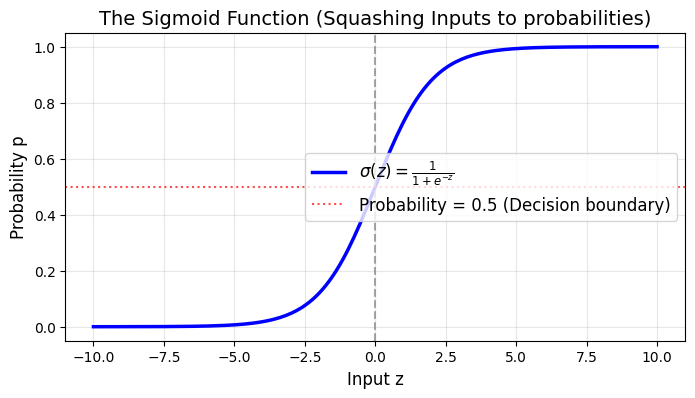

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Define the sigmoid function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Generate values for plotting
z = np.linspace(-10, 10, 200)
p = sigmoid(z)

plt.figure(figsize=(8, 4))
plt.plot(z, p, color='blue', linewidth=2.5, label=r'$\sigma(z) = \frac{1}{1 + e^{-z}}$')
plt.axvline(0, color='gray', linestyle='--', alpha=0.7)
plt.axhline(0.5, color='red', linestyle=':', alpha=0.7, label='Probability = 0.5 (Decision boundary)')
plt.title('The Sigmoid Function (Squashing Inputs to probabilities)', fontsize=14)
plt.xlabel('Input z', fontsize=12)
plt.ylabel('Probability p', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
plt.show()


<a name="section_3_2"></a>
### 3.2 Scikit-Learn Logistic Regression (Hours Studied Dataset)

We construct a classic binary classification dataset: **Hours Studied vs. Exam Result** (0 = Fail, 1 = Pass).
We fit a logistic regression model using `scikit-learn`'s `LogisticRegression` and plot the fitted probability sigmoid curve along with the decision boundary.


Fit result: intercept (theta_0) = -11.1245, coefficient (theta_1) = 0.3844
Decision Boundary: x = 28.94 hours studied


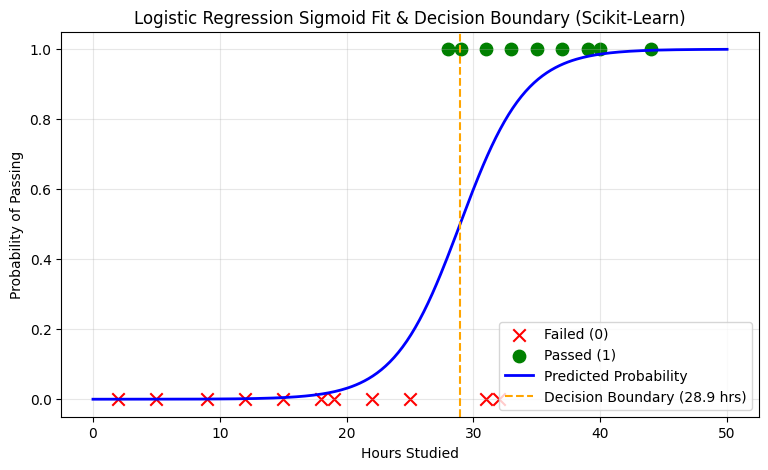

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

# 1. Create a dataset representing hours studied and pass/fail results
hours = np.array([2, 5, 9, 12, 15, 18, 19, 22, 25, 28, 29, 31, 31, 32, 33, 35, 37, 39, 40, 44])
result = np.array([0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1])

X = hours.reshape(-1, 1)
y = result

# 2. Instantiate and fit the model
# Note: we set C=1e5 (no regularization) to match the basic model
model = LogisticRegression(C=1e5)
model.fit(X, y)

theta_0 = model.intercept_[0]
theta_1 = model.coef_[0][0]
print(f"Fit result: intercept (theta_0) = {theta_0:.4f}, coefficient (theta_1) = {theta_1:.4f}")

# The decision boundary is where probability = 0.5, i.e., theta_0 + theta_1 * x = 0
boundary = -theta_0 / theta_1
print(f"Decision Boundary: x = {boundary:.2f} hours studied")

# 3. Plotting the results
plt.figure(figsize=(9, 5))
# Plot the data points
plt.scatter(hours[result == 0], result[result == 0], color='red', marker='x', s=80, label='Failed (0)')
plt.scatter(hours[result == 1], result[result == 1], color='green', marker='o', s=80, label='Passed (1)')

# Plot the sigmoid probability curve
x_range = np.linspace(0, 50, 300).reshape(-1, 1)
probs = model.predict_proba(x_range)[:, 1]
plt.plot(x_range, probs, color='blue', linewidth=2, label='Predicted Probability')

# Plot decision boundary
plt.axvline(boundary, color='orange', linestyle='--', label=f'Decision Boundary ({boundary:.1f} hrs)')

plt.title('Logistic Regression Sigmoid Fit & Decision Boundary (Scikit-Learn)')
plt.xlabel('Hours Studied')
plt.ylabel('Probability of Passing')
plt.ylim(-0.05, 1.05)
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()


<a name="section_3_3"></a>
### 3.3 Performance Evaluation: Confusion Matrix & Metrics

For classification tasks, accuracy is not always enough. We analyze performance using **Confusion Matrices**, **Accuracy**, **Precision**, **Recall**, and the **F1-score**.


Classification Metrics:
Accuracy:  0.8500
Precision: 0.8000
Recall:    0.8889
F1 Score:  0.8421



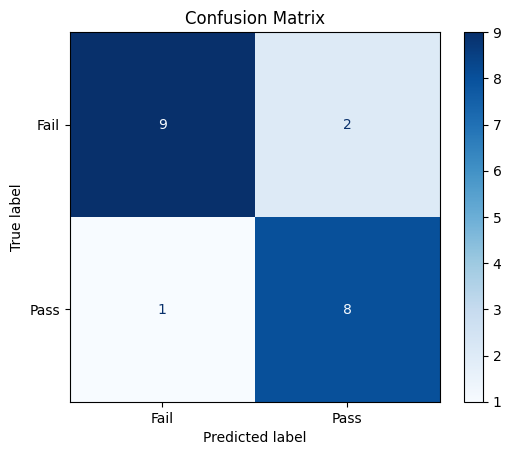

In [3]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

# Predictions on training data
y_pred = model.predict(X)

# Compute metrics
accuracy = accuracy_score(y, y_pred)
precision = precision_score(y, y_pred)
recall = recall_score(y, y_pred)
f1 = f1_score(y, y_pred)

print("Classification Metrics:")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}\n")

# Plot Confusion Matrix
cm = confusion_matrix(y, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Fail', 'Pass'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()


<a name="part_4"></a>
# Part 4: Code for Advanced Logistic Regression

This section implements binary Logistic Regression (Eq. 2.3) and multi-class Softmax Regression (Eq. 2.7) from scratch using NumPy.

---

<a name="section_4_1"></a>
### 4.1 Implementing Binary Logistic Regression from Scratch

We build a custom Python class `LogisticRegressionFromScratch` that trains parameters using Gradient Descent.
We evaluate it on the same Hours Studied dataset and plot cost convergence.


Training Custom Logistic Regression Model:
Iteration     0: Cost = 0.693147
Iteration 10000: Cost = 0.308698
Iteration 20000: Cost = 0.282212
Iteration 30000: Cost = 0.272906
Iteration 40000: Cost = 0.268448
Iteration 50000: Cost = 0.265985
Iteration 60000: Cost = 0.264507
Iteration 70000: Cost = 0.263572
Iteration 80000: Cost = 0.262957
Iteration 90000: Cost = 0.262542

Learned parameters: intercept = -10.1455, slope = 0.3521
Boundary Hours: 28.81 hours


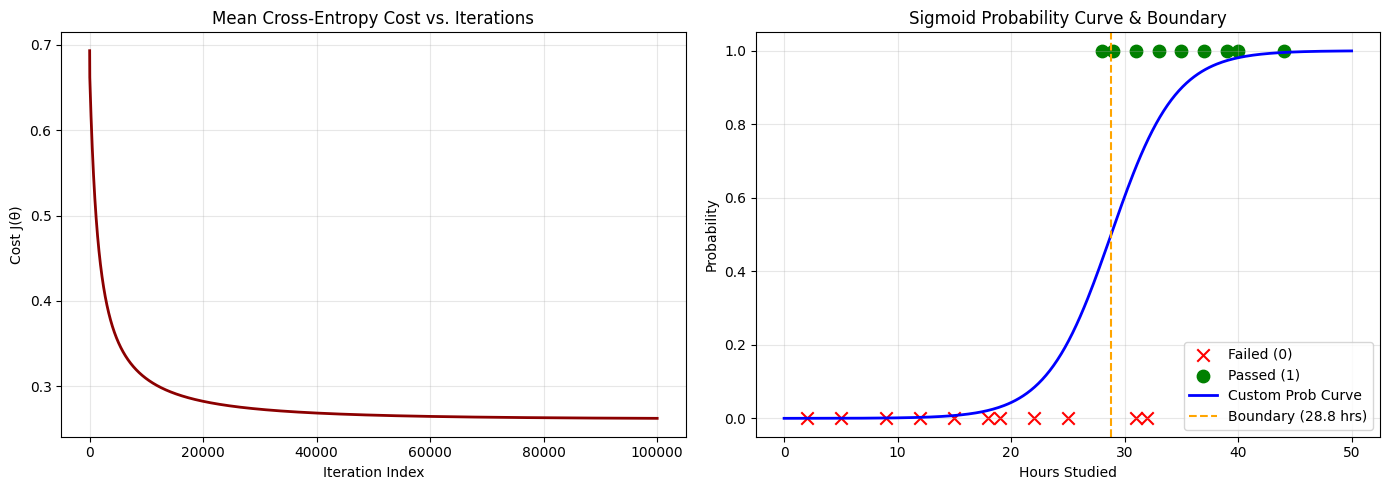

In [4]:
import numpy as np
import matplotlib.pyplot as plt

class LogisticRegressionFromScratch:
    def __init__(self, learning_rate=0.01, iterations=10000):
        self.lr = learning_rate
        self.iterations = iterations
        self.theta = None
        self.cost_history = []

    def _sigmoid(self, z):
        # Stable sigmoid to prevent overflow
        return 1 / (1 + np.exp(-np.clip(z, -25, 25)))

    def fit(self, X, y):
        m = X.shape[0]
        # Prepend column of ones for intercept (theta_0)
        X_design = np.hstack((np.ones((m, 1)), X))
        d = X_design.shape[1]

        # Initialize parameters to zero
        self.theta = np.zeros(d)
        self.cost_history = []

        for iteration in range(self.iterations):
            # 1. Predictions: h_theta(x) = sigmoid(X * theta)
            z = X_design @ self.theta
            p = self._sigmoid(z)

            # 2. Compute cost (with small epsilon to prevent log(0) errors)
            epsilon = 1e-15
            cost = -np.mean(y * np.log(p + epsilon) + (1 - y) * np.log(1 - p + epsilon))
            self.cost_history.append(cost)

            # 3. Calculate Gradient: (1/m) * X^T * (P - Y)
            gradient = (X_design.T @ (p - y)) / m

            # 4. Simultaneous parameter updates
            self.theta -= self.lr * gradient

            if iteration % (self.iterations // 10) == 0:
                print(f"Iteration {iteration:5d}: Cost = {cost:.6f}")

    def predict_proba(self, X):
        m = X.shape[0]
        X_design = np.hstack((np.ones((m, 1)), X))
        return self._sigmoid(X_design @ self.theta)

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)

# --- Train and Evaluate Custom Model ---
# Dataset
hours = np.array([2, 5, 9, 12, 15, 18, 19, 22, 25, 28, 29, 31, 31, 32, 33, 35, 37, 39, 40, 44])
result = np.array([0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1])
X_train = hours.reshape(-1, 1)
y_train = result

scratch_model = LogisticRegressionFromScratch(learning_rate=0.01, iterations=100000)
print("Training Custom Logistic Regression Model:")
scratch_model.fit(X_train, y_train)

print(f"\nLearned parameters: intercept = {scratch_model.theta[0]:.4f}, slope = {scratch_model.theta[1]:.4f}")
boundary_scratch = -scratch_model.theta[0] / scratch_model.theta[1]
print(f"Boundary Hours: {boundary_scratch:.2f} hours")

# Plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Plot Cost Convergence
axes[0].plot(scratch_model.cost_history, color='darkred', linewidth=2)
axes[0].set_title("Mean Cross-Entropy Cost vs. Iterations")
axes[0].set_xlabel("Iteration Index")
axes[0].set_ylabel("Cost J(θ)")
axes[0].grid(True, alpha=0.3)

# 2. Plot Decision Boundary Fit
axes[1].scatter(hours[result == 0], result[result == 0], color='red', marker='x', s=80, label='Failed (0)')
axes[1].scatter(hours[result == 1], result[result == 1], color='green', marker='o', s=80, label='Passed (1)')
x_range = np.linspace(0, 50, 300).reshape(-1, 1)
axes[1].plot(x_range, scratch_model.predict_proba(x_range), color='blue', linewidth=2, label='Custom Prob Curve')
axes[1].axvline(boundary_scratch, color='orange', linestyle='--', label=f'Boundary ({boundary_scratch:.1f} hrs)')
axes[1].set_title("Sigmoid Probability Curve & Boundary")
axes[1].set_xlabel("Hours Studied")
axes[1].set_ylabel("Probability")
axes[1].legend(loc='lower right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


<a name="section_4_2"></a>
### 4.2 Implementing Softmax Regression from Scratch

Finally, we implement a custom multinomial classification class `SoftmaxRegressionFromScratch` and apply it to a synthetic 2D 3-class dataset to visualize 2D decision boundary regions.


Training Custom Softmax Regression Model:
Iteration     0: Multi-Class Cost = 1.098612
Iteration  1000: Multi-Class Cost = 0.001082
Iteration  2000: Multi-Class Cost = 0.000675
Iteration  3000: Multi-Class Cost = 0.000504
Iteration  4000: Multi-Class Cost = 0.000406
Iteration  5000: Multi-Class Cost = 0.000341
Iteration  6000: Multi-Class Cost = 0.000295
Iteration  7000: Multi-Class Cost = 0.000261
Iteration  8000: Multi-Class Cost = 0.000234
Iteration  9000: Multi-Class Cost = 0.000212


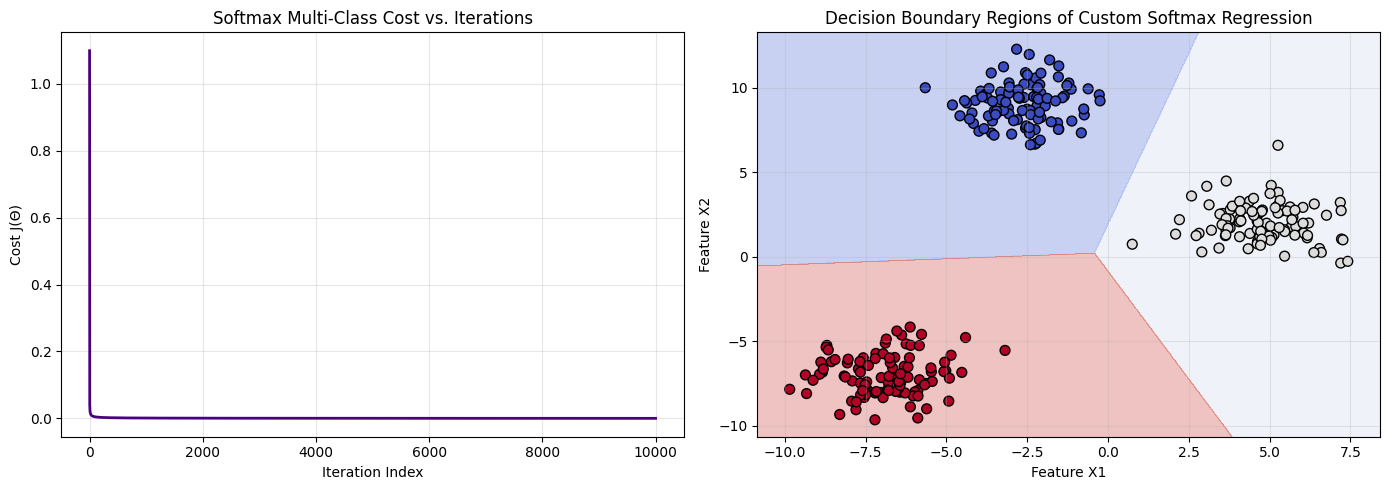

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

class SoftmaxRegressionFromScratch:
    def __init__(self, learning_rate=0.1, iterations=5000):
        self.lr = learning_rate
        self.iterations = iterations
        self.theta = None
        self.cost_history = []

    def _softmax(self, z):
        # Stable softmax (shift by max to avoid numeric overflow)
        exp_shifted = np.exp(z - np.max(z, axis=1, keepdims=True))
        return exp_shifted / np.sum(exp_shifted, axis=1, keepdims=True)

    def _one_hot(self, y, num_classes):
        m = len(y)
        one_hot = np.zeros((m, num_classes))
        one_hot[np.arange(m), y] = 1.0
        return one_hot

    def fit(self, X, y):
        m = X.shape[0]
        # Prepend bias terms (column of ones)
        X_design = np.hstack((np.ones((m, 1)), X))
        d = X_design.shape[1]

        classes = np.unique(y)
        num_classes = len(classes)
        y_one_hot = self._one_hot(y, num_classes)

        # Parameter matrix shape: (d, num_classes)
        self.theta = np.zeros((d, num_classes))
        self.cost_history = []

        for iteration in range(self.iterations):
            # 1. Forward pass logits
            z = X_design @ self.theta

            # 2. Probabilities using Softmax
            probs = self._softmax(z)

            # 3. Compute cost (cross-entropy cost)
            epsilon = 1e-15
            cost = -np.mean(np.sum(y_one_hot * np.log(probs + epsilon), axis=1))
            self.cost_history.append(cost)

            # 4. Compute gradient matrix: (1/m) * X^T * (P - Y)
            grad = (X_design.T @ (probs - y_one_hot)) / m

            # 5. Parameter update step
            self.theta -= self.lr * grad

            if iteration % (self.iterations // 10) == 0:
                print(f"Iteration {iteration:5d}: Multi-Class Cost = {cost:.6f}")

    def predict_proba(self, X):
        m = X.shape[0]
        X_design = np.hstack((np.ones((m, 1)), X))
        return self._softmax(X_design @ self.theta)

    def predict(self, X):
        probs = self.predict_proba(X)
        return np.argmax(probs, axis=1)

# 1. Generate synthetic 3-class 2D dataset
X_blob, y_blob = make_blobs(n_samples=300, centers=3, n_features=2, random_state=42, cluster_std=1.2)

# 2. Train custom model
softmax_model = SoftmaxRegressionFromScratch(learning_rate=0.2, iterations=10000)
print("Training Custom Softmax Regression Model:")
softmax_model.fit(X_blob, y_blob)

# 3. Plot results and decision boundary regions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot cost convergence
axes[0].plot(softmax_model.cost_history, color='indigo', linewidth=2)
axes[0].set_title("Softmax Multi-Class Cost vs. Iterations")
axes[0].set_xlabel("Iteration Index")
axes[0].set_ylabel("Cost J(Θ)")
axes[0].grid(True, alpha=0.3)

# Plot decision boundary contours
x_min, x_max = X_blob[:, 0].min() - 1, X_blob[:, 0].max() + 1
y_min, y_max = X_blob[:, 1].min() - 1, X_blob[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))

# Predict coordinates
grid_points = np.c_[xx.ravel(), yy.ravel()]
Z_classes = softmax_model.predict(grid_points)
Z_classes = Z_classes.reshape(xx.shape)

# Color map decision boundary regions
axes[1].contourf(xx, yy, Z_classes, alpha=0.3, cmap=plt.cm.coolwarm)

# Scatter plot actual data points
scatter = axes[1].scatter(X_blob[:, 0], X_blob[:, 1], c=y_blob, edgecolors='black', s=50, cmap=plt.cm.coolwarm)
axes[1].set_title("Decision Boundary Regions of Custom Softmax Regression")
axes[1].set_xlabel("Feature X1")
axes[1].set_ylabel("Feature X2")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


© 2026 Ghassem Tofighi. All rights reserved. Unauthorized reuse or distribution is prohibited.